# 🏦 Microcrédito on-line — Métricas que viram Decisão de Negócio

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/oness24/microcredito-ml-metricas/blob/main/Analise_Microcredito.ipynb)

### Análise de um analista de dados em uma fintech

> **Contexto.** Fui contratado como analista de dados em uma fintech de microcrédito.
> O time tem duas dores:
>
> 1. **Classificação (desbalanceada)** — o modelo de *inadimplência (default)* exibe **95% de acurácia**, mas o negócio sente **mais falsos positivos e falsos negativos** do que o número promete.
> 2. **Regressão** — um modelo de **preço de revenda de veículos** apoia a definição de limite de crédito, e o time não sabe se deve cobrar **MAE** ou **RMSE** no contrato.
>
> Meu papel: **analisar, argumentar e propor melhorias**, conectando *métrica certa → decisão certa → impacto no resultado*.

---

## 🧭 Sumário Executivo

| Frente | Diagnóstico | Decisão recomendada | Impacto esperado |
|---|---|---|---|
| **A · Classificação** | Acurácia alta é uma **ilusão estatística**: prever "ninguém é inadimplente" já acerta ~83%. O que dói no caixa são os **inadimplentes aprovados** (perda do principal). | Trocar o limiar de 0,50 para o **limiar de menor custo esperado** (cai para ~0,11), monitorar por **PR-AUC / F1**, não acurácia; usar **`class_weight`** + **regra de negócio híbrida** (fraude/atraso = recusa automática). | **−21% de custo esperado**: calotes aprovados caem de 20 → 7, mantendo aprovação saudável de bons pagadores. |
| **B · Regressão** | A diferença **RMSE − MAE** é o "imposto dos erros grandes": carros premium/atípicos inflam o RMSE. | **Contratar MAE** como métrica de SLA (erro típico, em R$, fácil de comunicar) e usar **RMSE como sentinela** de erros graves; segmentar por marca/ano e revisão manual para alto valor. | Limite de crédito mais justo no carro mediano e blindagem contra erros caros nos outliers. |

*As seções a seguir sustentam cada decisão com números, tabelas e gráficos.*


---
### ▶️ Como rodar no **Google Colab**

1. Acesse [colab.research.google.com](https://colab.research.google.com) → **Arquivo ▸ Fazer upload de notebook** → envie este `.ipynb`.
2. Menu **Ambiente de execução ▸ Executar tudo** (*Runtime ▸ Run all*).

Não é preciso enviar os CSVs nem instalar nada: o Colab já traz `pandas`, `scikit-learn` e
`matplotlib`, e os **dados estão embutidos** na célula abaixo (gravados em disco na 1ª execução).

In [1]:
# 📦 Bootstrap de dados — grava os CSVs a partir de cópia embutida (gzip+base64).
# Roda igual no Colab, no Jupyter local ou em qualquer máquina, sem upload manual.
import os, gzip, base64

_DADOS = {
    "dados_credito.csv":  "H4sIAGk2JGoC/2Wc6Y4cSXKE/y+wb1IoxH08DdEackcEZoYLkqPnl30WWZURHEhcCb3VlXG4m5uZe/b3L399/vj055e/fnz88fjx27fvXz79z9/fv3z8/fj6+ePzl8fPL3/+99sn/cf3L79/0+d+fPnx+L+PP759//Tj2x9ff/v68+Pzt8d/v/348ffXT79/fP/46+fXj8fHz+8fP759yuHzp5j+fPzv1x8/v33/+tu3T//5/vE3X/rx/fcvPz99/vKfj7//+Pnvf7UY4jM+RhyPkh9R/1LvJT/DfIT1P//+V4wh1Gd/9BYfuT9iC4+Y62zPqd94f6jG9Ezz0Wp/lPKIQx9KIz5Lv7+ozNCeJT1q1z/97kiPPMuoz8GH4vpQym08+3z0XB65PWJI+hdafOZ5Py01PW32R9M/PqQHpxZSf/ayfahUbaQ8upZU9WUxaXMhl2ev95pSGOUZtbnUHqU9UtYJ5Kgl5O0EcguZH/TeHvpA1Glpc6U++X/e3xRTfc5HHc1HqS3E0LWkvH2mxNierTxGGHzR1LJLnDq47SRz1tEG7U170Wf0PfpJ6c86tgWFnJ41PYa+oXAd+lBrKT1D3reWA0+vTZemz2l/2Xu9P1F6e0YtR9+doj7RagrP7Zxr1Y2Nsdaix+m0Z67lqZu7b5VNxuhbTePRwyOH2CNbuENoFn9PnelRolaTtalQ6zPU62FRm+qxPKcWwUVNn/JoSdcV7y+qZeZna3pK1NE9atB/9pHY1R2KSSGlu+wxE2aKlUeqI8/n2O69jDI5rTriiiB9aITkU73PJ9fIXlth47pTxWIdCpgx96hOg1SY2rCW1JxG9Vm3FaWknWnFQz/kSrWolFp9pm1BMYXwDNpY8qNKfczeFD1t+0iO4xmbbqlqV4+mwGqjKzLTFj1Kg6d+uSnKCstVZPQ2xjNtX1TCDE/tuCdfK5uPrYSysjW+w6c8lYQ1adHVH8qxtvyMr1XrzmpcIdUUYASI9lh0HDXfH1FyxmdVUuiytP9ErJURlat7QGd98dSypxJjgC/6P7EqsLbriE2pUli2vkIwU4U0WZm6p3PWmQm8HGjNiRGDTlr72LM5AB4Kidcx9jILyLTDwiBRq0LECab1RwV+2y5eSDmeQ/89oMNe0hhCvJnuvetQtXcFRWfjD4eRUIHg2JNQuNEMLnqUjl2XoU8dGFx5lpas6NS2Y9O/WHpgie8Li71r74JWnSNrrtyqMvhZ5vWhSNyHCQB2cEUhqktIs6dIlr2DaAgrSY6mZ3H1FTCfutZ/xmsDesFyAQhrnPFO6KR9cMtdt5/18xTA15pInxsSVQGADy4VbA36kI4t3WFmvFtPL8pl7UaPEnYqOtoGdyUrFUgyQoOnAUdTK9jPMZXcqAlDaaTlAIsRGIp7Bg1hdFWsVn+PNjDK6HdBAKqifgAuUn90+9SqEptT8f2sHtiqjloL0PZ1xVnbL8cplqA700qbMkdlk41FHdFREEpaJbIOpbTOWfEUQ+2FG7ohpufsVStCC0U6PwZXHdKW0VTNdMFZYEFRYZ4PaEhtTkC46yIzGMSNFN3GftKFXagcxnVCHIKSAWi6n9WFVTrBFpoXbficWrQetpXDVrhDMQ7fPeE/q4IxH4EmzH0KFamZ7cG6QtHTet9gaCpgVHj7WMigkxyCgGfYICYNhScr1pK1CGJyJC/6vZ4ep4iOIEFQDnoIqBUeLXBl+0lPIrjqN5WOcXCvaXGPX7OjKBXfWVb6BAve6RFnNDh0fZmOKFKJwlDBS/0fX1TngnOtKpeQOxH73n0a2dAteDScE9siI+EGT0K2Cir1pFbWN2m1CutxXOxU9IBfXfsXhOucteyQ2gHVRQj+FLY0Sst4ANghiB9tzCsHEShFflGIaYNJn9Tpi8MYhtML0mpzpIkxLPhMCu0VRL9uPi4w12HqTjiz97Z0GCaZ4jaumwqAWEmYPG7Qq5UIEpqLLhHU1BhiOO2sQXFBjg9lBl8klguiRdL8vaA2RQgU+L73B1Sxi4j1PTcSZ6q7WNHq0hrzCCd9Fdg9Q/OHdBfaOAWfRW/fVOGKwmCoFSWB75uiZxdpiIsRNN2Y+BBEkAzSN+XSVHTKTl9n8KE1ICiYWOWowH62uCNRc76YgMBxdTajsl1i/40gujPyTNGjQ0+UNZEdlZgditAUIkStzwXEghpgZo69nimroDJxrduRNsSS8obEKagqa0ktLUpdITxUvRD3ai6Wr2RuepRBppBuir+yU+Gm/Bx8aKGR1Inyo/wiTxqUDOXRwWvtTfcG3xlbuCUVa2AN+NDB6HM5x3kGSRWNbHzPoDjovxJlViDtBD6poHPbDcjLxojYRMb7HiWTH3QnGucIo+y+kYNYV4d/DHwmgWZVBbXUO/pTU/gpPnTk5lYcpVjGXCnyrp5jslNjSHOMpKDVHWddEXmxOWUXdRRRUP0YO2vURxr1JXnzUCMtetWYVzqO2QnQGVxjuHyFqE4o71g8pulnywCRQFJIIqK/E++y0ryLg/GbYilZZC+Q6fcBha46gAqCf4F74s5BIQr/vRHUQNNNiOGoA3VBsu1HJDI1KHtVH4JfRZSp8SgekJWJtIs96EG6YwnDtFRg5GmSWxQ01WdfvEJpINX2bKyRvQqt06XdxGudVBtj1u5Vy5GkxjyKX+d37gNSQdVHOuJ3WgooFAQqh7jvoqz8sn7Y0CVUM/E/0j5s4l75q4Np7UI1ElInCsjfqG8hpiSjVsE9VYbESgZk5l62suupEjTzIvoChwryjE0lV+mTla3ZBF1HkDiyowo14cBcyhRGSHJk73fD9EJdSotZazGJWKtSorsaEMhbVBFFfChw4F0sMR7QUArcTrGENB1gtkLtGfZAGyqUwIdWULEa4I5dv7fndB/F5y/dRAYRkE2lcemKKz3E/U3lBmAFuQSIJEieuV/IHw0gTnxl5INSBf5LvtZVz1+KYGbTIjFapPmExrtU74IxFYvVWq3gonNShemGK8iDcPrpSHYk6ZlZNTDfdAbY68IdJVUbC9LRKYJUM85NDEqfDX8Gfg6CuhDlu6aNrt9ZCp9n6ZSSSlpZTPa1aOJR0TFgeh0bQGVAKBcPRqwoitDvsrwtltVUYjbeGHGksByQ/7pXZRoGw2i7mzAbFb4rnHETqMUSUUrXo5yJsxdYs8GKyM8or37UKQW+BaUlVQGGtMLDA2B51kJWr5LJil1V3D2BREymDSsFsZIDGSesiHzPvfXRzKH1dUu9wngxHNpWXUW0nYmS2YoiLRjeI10BDm41SIw4Ag2EPLmfc5Ks2ZE6FoBSF9+W7jQHVxGEl7yDWsEZXF/SKmY4ZyLS/RXUr4oXOddWL/WOcCBj+mYTvUghFcoMXCq1LiF8Q2PHtilLdTctXYevI9oCWhLCzpfWYreuo1J98/el5mivUHVn4VmwoOzsdUv7FpWtCo249kV6iCaS0XdqCOrJsXzZXzhhIt+3Wozeu30ThZLFsiNXWbc7DnHArJDA0SddrM7CM2wp3/KMaJhhVqAgI41ghPEgTcIqFFyPS5kDazDpvXwI4CfXg39IUcR1CXWcFmJWwijMVSt9jphls6dDVeVZbC/0tm6Mtev0x+55kgnNXFewkXD/aqiH+aVkCOwr4/kpRCJUZdzpY0xMrgmTUo8GsnWqiJ67NinaphVXtn1IBQtQwd0lqDoeLHGLoMewkYRU3T6SVOwCLDEvRknEKuPHWesC6D91MkDuoOyJjeyeVgaPq/0IIr5SgUDEssHCUNJAoCSpuQjxTSUY7KTuMLXsw7TsTB3yLDMsYI0vgFbpFSqgXmBUEDiJ/V1z9Gt5vRgPbb7r2iap8g/nR9uxmtDtB4y5Q2srKkjN9uK2+kw+feMEiKqkU1Qu6prbqOm2NUh2sXTwRxVpaQnK+BSSlUuU2GYSU0S1X2coGJL81eZ3uoT5QLkqeB8DHmArN7Oz+xBD4OgVWhDGSwCHTiRuFVMJXwkzUt4aIGFrhbxE0LWoTvzOaphiQf62qW/fbfGK1V8hMcmVHryaUnk3N33Zeh1vtbtGoeO0ud0VTxUPywR/uR86kdhXW+UlXBoOp0JaaAitYuEKln7of4nMSOp6Z82CKyfl5lKT6WLvNGgq7aBsL3J2DDvl/Cy3UMwQWrzIvB5nY3Pq3MLeMekUF532pYCEQjXiQm/IoKetPItLu1Koa1G9C1viF3yLyNMgC0BjLXWeVv6Ig2rniIRUURZLPYWyALc778WUymLmjc5F22v0UDLaHhyr2kE+qVu7XylKW+DGbRjydC9TROa5G38U1skJrg5OsqvbfIq3coOeYNaGBSA6K61Zejce9qAYQiGPMJmQrQrr63tu5ZLYF4fIw7C8Zyzl8D3FKzLSCa/aBkgDzgWWuy7JinZop6Q6oTZtSeUDGKsAF4Xclt4ChEPO/XBttNMOqapKIyhcQgnpxuIOwolWz1hfNC3cxPpUyA55V+nMlWVFziXsw6zjENti0G4IIdrTkgvK13KvyDdGY3Cs3oqyzJVBIZPSfR2i6nkVRPsRKoYPZeIkOW9GGYh8VGJfFRGrqIB06R9gXUZaRRN6ZvaxLWgKC0mz0WgKKU6gyyWYi26ltbsjUkNcXVfsCNymeNChkDhI6jgHaSM6lkzGxK3kZay/2pbJHAIfEvL3dmd1EXpaJld3XxIYMacK4f40kpPQj6t3gJMtQXEaja1bvKoCLMTGK1AxouptchI9Me1o41bjkGI9ti3x86DFqTS7HAD4cOQne95nmj0VjbC6qWmmdBgkOrEE6NDBs+TAt+E+9h5egaJwQLRm4+IoE7SK9/lEDEzKx7Bqj0AN+nePRazIq90MeBIdHaWwpb0kaqN2dHohiXKVM7/W9o33ZWhdXRM+Vkc+pW2mOacinFfMFxqQWvAeP5jCWHWKencdOaQWDhosvmQMsASga6YnZXrfR9ILJ7QFRBKtDrpPCffqENqqQAq5SaquiqjaClIdXFF7IKDHYsGopQHz27HcphfYORaccQb4Jek2lwuGGymf57JHcBKYB+hbj0JswpJxYoxFE6I8fjF8i1IAF7viHpNcwDQtknm4A52HmXJf3aAk4YYtufmrq7YO2nIUQcyBdhiQjZNGAowl2xS2Req8vcyjS7aFvrB8eNG0gmnJl12KK5k8ZlDcc0y0Cwtcr/d/gFATiiFZPQUwT3Cl+55sv1Kei9V6trK8HeHCbAjNqbAw0cp/zL0kZOgJxV37YDlIkkK272eo04A8e4qgGaeqcPY2D1wRmru0Lw0d3FNa+X0ns0kWIb3GJyqiTee6R2JyLa7VJzigJ3P281F4djqZhu/YaN4wOzLD2Z4gm2Zz78E2fiBg8Te2PrIenbFVg6WoHte184N0cTqFlZp0JOqhIipzo3vIr44K3QCGPWAehMbYcKPV0SjpjQYwXXaM9TWDc9/6VDJpYx3aZg9K1YG5i3FzV+lXZRMch9jI7qIXFcytPkO64MUrnrEPEHfJDunetwWNF5A5m7mS/kuZFyt2cFx8IWO/znTWOdHI/nIEKRjQqsJsyl7CE11BldS+iDKBNEedR3szd2mHkVfzarVJlRfhoGYK+xap15AKm/8lz3EqcfN9NEBZanTCBvSsdjSLusOjMRIDvesUqng2E9N0z6FAOJqjSGHZ71mE6IraPVqVPce0AqS2etgHMcTkHnXlO5h20jMVxTcuRCfrxQRszjM21WGqde4aSEWVy++0ydgXbWKI8d7mqkzGqIyJcEBwcB+13Xy6OQWbX0i14gxiNeitj7nPjyhbbUBNq3EYbvdQxxazLXU3qRkMAsypDQmAH7tjHoY7cX3a63RWMxzTN+yMWZvlumBC+gAkVnRlHK0pRbGngGZaBD80+4b9NFBCbO8BtLQ616kptMMebLlYX7W+epPNXYVmeritu8+1uSVMAn11cbG+mwRDVFjUpVFeAT14V8KSPZhFDybe+ZoRwR9sOR9WQkFxkiO5eibO7UmhH0d5Z1sQ2ChEevOcEZVtKrb3LicdHJrEwkb7xjgk7iBtdgOKU5tCTLlZGpX/9Zk3ntPFXpkMwnokyiQompjiWVujexhxEVygrBNEm5iAHCGHkdq24KgONaSjR+4pJMJ09chpag5O9U3xLCOTHePXVKH+XzFO5+eGaM06epblcsNyOxste99FVwMNLGsoKqNLMER2m04Ix9BPXa1tonT1bduvUlOhgfmRMDUE1tKox5Rfw5GjSZpdzZpHH0a9LVNzcoXvjDYIzAcwjdM8CW4VhHvu8J7qiEq1wTL3Uj7ddhnLocaE7XCCXW5muDPF0346PjdhXY4IapG2w7BMevWk56DLcnRJWRKBuA4SZBNiLAPt5TR08SFyAxSt9owVioi5vLdAq/sQNDkIIyA44MAeFkEjNxRqxShjCIzz6DtIkNvEv/ogAXWP9j8a0nO6VwKRw6xoj5lxW49utMcur/iwPW9/fG9Zd4YIFcr9IlaQC0HMPEaMUijuDjCwkZ2D7mt7WPS+fRFk95GLP0R7Jkp/MAa1LWkM62gsIuxFiucq3rcNmfPkWjGi3E5DJonr7XxH/H08DWFrgkZfN6JScSeerYp4YsUs5hA7pq8i5hh7YfeZtWRfRsdlGWMcJK3oAth9TWnZxjTJlSX3wBthPdvafVyk0ZM2xEzZj6h1I7UQaZnmWGjzbEgLS61VLLn6Gq9T3vYDXxOcFUur9jfkBxWYfaxhxOp+J4Fm1696DDpCi7ZSxUgTjyt2a6HwlCHK99bnUfXUsfXAaC3zh8yswKw3eFxliZGF4cKIdhX/DVsVHhn/iq2vhmuzZXNSOS1nOmGz+22JrqbyoB2DgzZ/6mral7Z4QUFltbqPhiVTUNilvUoKHxNDLe/tkGr7w60wMIS0DnUe2BcxzADY8hJ5OUOo2s6wXKnT4gW2T3PX4ncDWTp+TVyn1ShHTIuV9nvVa0TA3XVhsiUuaDuTB/M2nE3GWdrkhFezINDP9jotDuYUUWFzHGVPRYZ52J4D6lJwGdtlfqhwRQYrtuZuSghsmnw2WuDP2sgejlKUnQtqy0BMOAES3pXc36a1uj0K89RkVBMk6dJOLjN9Hu1yY3DJSs6HrSW+2Ty0gJJZA6hQoHMqXSnjAsqcER9yBwrqeMxymqi21U/NVNASMKN2QZ1H6/SJm3UeJEMk9Zfpyi6WjufZ17NwAWhWhmNIotkJy6bVpmCNeJhxM/6qxB8UqbdFrplHaeWEYpqOjGqMdtXhiAwuh0uimsfNp2VX4b9pOcar7a0FQA0j3EgEd7aKaRuNxwLAOWU6Oxv3VIhrWL2FV7yynr6MUdwomicMWe8TGx0XEBFQlt8foOgjpnvkiVAk8BmFxlwcawyJcn7rISuLYSs/oxiGd6/4OKydhAMebW548ANWhIvlnnTa5iziRaure0tC1LjZdT7GaPwsHs80BRO5a+Fwsz09R1Oov+Az0dtqR63CSe82zsk9N7czLsmOw8yiNFrywWN4ndZ+iOEY4R4D2IseuldKT2hBDNt8nQVaYgyLJsUy85FykxzeVYzC0xMrjNAsgzWn8evsWGfmCD0YHa5wsMStzaM28prGKvoOfY8kKGZn3D3Nbu5UX8M44F9v7X5DxhKN91FUX/prwJI5mzPRaHnHp2e0ytVbVJHBhDp6B8smg6m5BbfmBDpSY3MJldUTW6Eub5xKS7TtoiBC1HFD9I9L0Z7GnOM4gJSq370p1SN/uN6cUjhA3XZWTJ4Z9xQNg1YWiXuHXwXLrYFkpwwXQ/hUwj2BvAq/79u2v6IW6yDTj67xmEfya0u9r0kJjiliiBy+d+GbhrkIxiQ1B4dibw50Jp10bGOhMeXGJva+7ErbXV/cCZM1QBdewwJvICmeTGPAFlEEuM2Rj1H3xLwJQ7O4bUQhM8rprDJMHLol1pcm8od4rWlvsJi7ajVz9fGYIBwExDFMgbWK1XE5u7xwVMppGBUInU51MFm+5vOjaHk5Wu/JIzG41Wt2AX0uYYNnsb15wDseNgo9Vu+50HxO/7Qh8INitlUb7eO0Mg5zrsKmGaFz68gis6xXQ7ZKhGPe13h+Xs6Lp6/LQTBXo3d6MgpCpxrfj2mtHpahhRNQ27JCAv2dtAHkQEtAHXVCvLrBijyDfAwYNruOxkcEBP5mTIcfLRJgXlTMKx/2CpIqxj6dnwkGj4vnNfWGycU571IGi8VyqqxpADQq790dqEYtIp9R8lCi6HwdRwUtWSuqySOYyUK+U0J63Nkl6ZuWjKPbgJgp5Rw3YaZfOohxPpAoRrcW86Fie82r2ZXXhCX8aUIo9kTMUECe1sPqwxQ34OI581inR+9f6pNBMSTh0ccs18jSdAvfzxtQoLfTXssaB/aAOt1ynCeF3i9zo9WzI0zS2LzDdqYbMDY1zIuZjexo6W3a49GHo4edaG3q10aYS13humXejTlqqHB/lOW54gdhKfF6VdlRj7Jz5YdFWB7MjLdDXUS/BSTJaU1opoYL3Q8OqppapkekPEYF9ENC22G+4MDX9bZq9I0o1KVc2z54AXzTM1+vhjLv2z2IM/dWVCx2X8YS+7ysif1CQMZNXHUq4chrmsgvZkU08OGC6wKQaetSYDWKY4bWtgGNxvQ5vDjW5fD7TZ81M3OzEVUCT+tStG0Cci+zHx9SQfF0IulvU8C9m9LPF6FoB+EBrndPyH/rxLgXmeaRcE9OlzWJmXi5b5fptN+5jeLsz37jUPK2b13RhBcn4UnHYY3VEFl162aWLCi8hmXcFfVrnYwZ7iQLutYXe3Y7E5EBWd6HGjPFm2Yl8RhWB9Yvf+SdP+qXipu010u/NYdTWzDMGyxAbBfwuy5o+3ufsWBO8XbbMhaoenSoD7/sNayIiVPXnEOS/rx7ErYdq8fhWzbFZJRs/DqAm9xS62voaq6pEw9DtO2L9NNG/5C0NrtkVfghHthLb+c+r97g6v7QPy4xna8pByF4XkPhRn1oYc2n91BmXfC47BC/BNj70T31wEThTYiw3l7iYWnN3925iKfGLOJc+qK5YZlOQVhjtx6lXBEk6MH0S2snkQcMR64q0/hkVebtbAaG4UYaL5rSkMPjrzR9d4k6irvZ9CK5NXPaeGm5+I786FmQ0VfvDwUuUXjM82qr7qUjHmA1IHY+P5Lpn+JzXC/w8NrEEPbvVE4fwQPHUbTZQ3cZIrvb0pgKuTmor9sALeMxe6A6gLgYF+GBF3pAvbVjVCgu3WQhhzrnlbSwvxya/GrCvCbJmKTrY3o44p7/ytluhbvUUufkIVN6m3+hUPbsSlmMUBEwDVzbu6pgFCFWroqH7cJc2U6seDWf5FltHy59FsB9e1KhncjQEu3MtEI14pHvlbzU7pTrHpamU+uXlHeCVmOxL4C75TfmSf6RjvvsvfltIPeoBy//dCXq8XcJlkcal55Y74UOykjZUrm6p5HW7HHwn1MQG6vlmKLSGbsDWsf7fLjQASLH29tDO7wGQ8GN4Hc1D+viGurCt1ljiEKzdv7JgRh4KdjjvatjgYgLzMQc08DR/KCG9YcSeBmD10kOqlPGGtnihNJ60SwycLsbaSpwfjF0llenX8Exf1n1wlpUhyHab/nVbeuV+UJeebzGAqtfxcsHFVQ+VjfyzCrXe6qu135H+f3am06M+lTX+4y8TtEC5/pPqPd7zHj+ynjaILtGbGsMquVVUAfTXaUcZOn9ZwDCq5elr0nna1gxrxFAxHZz51W1PtT7JRK/qsXrGWvAbjnDOvcYDhnt1zxAlHyBhuKxxTWTuVWnuFrvNocefmSp9+yG/VNEyfCfN1hvdWRPv+QD5syJW3g7cXHST9hHvAUR7ld7AjGY4Og+xvFuUGRoxq9j2InjfyN29j6XMdo1vj0uQ9N/HQNA2iZUK8zdrX0TV7uWaTV70vst1or4Ks3E1vPvCfdyHlKi2l4ebMxuFQmWT/WXZ3PD5+V9BV5a4DWOfXTM9z7revMWdyyjx45DpAuPBX8xUps/lMG8+905Ldra11/RCH4jI53v08dJ0xstUdefyODKal56483/q99HHDO+G1CD8c+9s6itrNesL3ZHDai2cPa3Y2Lx6wedt6HbYkp+NWsfg8EN8F/t4K9jzEskjnAMr5SZX1iWyuKtLdTjWf8PpNepJlZHAAA=",
    "dados_veiculos.csv": "H4sIAGk2JGoC/3Vby64lt5HcC+g/OQvmg6/1AIbhxSwMY7bGhboxI1jW9XTLHvjvJzKTLLIeRwIMWHVPFYvMjIyIzPrb318fv32+/vf3r3/9/u1fv/z4/PbD/8/Xz98+f7y+/fj94+vnX3/++P798/X3j+8/f7z+8f3bz5/4249fv/xUs2h/caL+6i99yesPv3z8/qKcKH/5iXpOGRc5v9KLcPGP//7nb18/fnkRFeny5SfuUov9geCy/cFfPv/9+fvHq1dK+uUn4ZTELvOLcVlff/j8/vWVkzLj5rjYyB6tr4af6utP377940UJ/+CqtMxlXlX8/nj2+ANtrP5zPDn50v/zlx8/Pn47/qCL34B1rO2/Pn/924//+/jvb/Ynklv/8pMqVZoLlLX+Qq3h/ZlEx+slX/94QiHNFU8omnvC9dRf9XGNVWnbP3398ROXX8Q194bLlJVjhXH5P/7n27++f/767fdX7kL2BOaW1V6y+BNoHE/cvvcm9ns8o/j6fXvnswnb0+JqLG6/2jRlWxn+IuOHvPYOt8S+tHGuhMuXvcMvE/4k515tZZzwcNs6Pz2pTRAX2N+k1e4fjx5XiaQTtrWVGRbYPfy737317sePcx3BEQtcezPfvkqheET2BZyPv9akKQKb/V9fATfpWHwpUnIsPq+d45KpWEokWqeyP7kiIcjeLuWeY2t1D5vx6NyYKXZPIm382LXkhNtLk8QrKWS7v3b1ly84Hj91i2s9bjBur6X63jKP23tMYOdJLWJIi8y1+bFvEUMtYxGRNN3j6batCLmaImbpsjzCZma8ge2NPP9JT82Cg3pimrnH2wYhJBVx3Sj23wLUr28PYbHUo5oSeXDzCN9T+vpSueLAIj0je9ddSlG1IODAiOOcPQgAP716jBXxzRCHn3P+ABdbmylwhIhkaf5+wL8aJ0RxypfUz/jfPfMj/nPt9vPGhWSGrl6haRyDFp3vtmIIwGH51YgCtZsv7gCW0mu2pVcPfY8/3mBbSmfESEmeFX5E8WoWItjN7gGUAOo7bpyCDxFEupcE/22rVezG2tKeOfO53fIY66JWHtBQgKKWVVRrW5cvBy6lJMudUmgvKH/+9tvHP39F5mgrDnqt9NvqOoDW4Ba73iRCKjBl/vqAzNbqyJ3mf3ACVABepzjzd6fWgZ81zkX83/1POGkzdMmdA5dk4SYqQrXAyHjPCIzqMXmGe81zd+3M93tTzZZXhQqPm99QE+UQT+iZ+0DNWMA1bnNRmrGxQVtmBK1vUWdZRfspLUmtXG2Fdy2iscc/ajcSKU7CcerpNg1/vEfL6S9691hFQh0FVCa/AMR3W2oqPeVZHuUWyF0jVlJzKHxaQuXUVjzvL4IEaxaPmejIUp4LQAFRYw9Kve/kyE8ah6hYnaXE2qOJD0D+JB5qyVNlRCpdI7Wm1gdri8q/rZ0JKO2n0KUFuj0UAgWD2Z+/QThVxu8VCNQWNTqRk5LYIrlJLDKCnQ+QR46yvwSwMmpN81pzeYmGZBkgpicOAgQCN8uGsXG5+N4eP8+l2fmCPI3tFb++oT8Kqb0CciIttJgBUFSUHcla2rFiL3SACkBSrtXxgJOvf6Sj1RTb4Ew91i+eSpf44lwL7QDuv834kfFOFMK6iOUoLrkhcvDU0uNs6EZAAJUBc6M2qf/4QNIEEmDsDey2zBzeURJ1gZpHrbZVH/YHaG2GQwBKTovcrTvg1Y0iEepYbzvzfeAROB6J7cl3dtqoOAHFDeiB44D2pjqPjo+rBc/31Mbh5R1nI30qNsAgLDm4jNc7IQe2PWpNL21nMAcKQrJUewKOL/dFvG84WYAuHDsUCxzByzUoXCdu84AvCVqy+hq4cK3xiOdyVKTWQYEigc40sykHiYpi8XgGXWve0fp6h97eZkDNFgga9VQvAhAFvwKAlUcc89jqsQuoIqEfi4w45ZM87M7OiqayY9C2xVz8ECo5jTy47Hn5PTjYUSGi2INgNld2SWYSXSqxIAaw+B7s71Bf8+b2eNucrLpCJO+bYxTbWKwGF3IWdq0gOFyrUAIULTML7q9AJtNyBIE+JxKkRh4cVq60g5GuXpVTrHW+StRB9WSBlEuLNpx+3iGR/Jg08CS1sYizlMpQI7JT4XEZcBIxMmhfOuWqoABZoStctkTSSxnKITSP7bnkQEct4ykUHnIki/OdIwTW5ZKNITQQ4rSKyLkIIn/64MF04kIiyXCUIR/aLOB7BcqVbN8g/yfb0lN2sPYsVw1wck/UeDhw4KS0BkDKiM6Iv5HdW/KTOQO4dx0YHtUxRCBUgylYVUlr13Z4kxrynDlPeX7lmVZYSwqiKzfnQPIwLXhA7148XAVA4LpyG/L3SCxITzEaDnkcb0ZDuD/waPxp2QXSqTgA+9vTofeo2ng7SMgJrPqGo2aJwNCXv+YlMsYdDha8owcWZ0+BQJR9FctBce8MOaW60P3qEVjo1RM9COZIQuabkZc3lp13AEtb0K4wNkqs/FaakM5Rmia5mKBcqmnHCtWsS4BsKZVZ7IAhx4Y7Y3uXj9sX3N/9izw9M1rqUUDsyTaOyqGaj2zHf7R4N7YespX96tnNIpJadzK/7XkD1Adi5032XuRVDlcRmzdsL7nw1iVhWUZ812cTRITC+OOhoJ1fFGBJM1eQlRfpX/sPveGqBNzCVRzglMjD94paEC5lhddkjor/YAmSULZbnHDxFNq3SVpKbZpnyxiAqCSP68J5eIL96qxMatXP1GQtv5knWlrzsuza4sIKejFb11TKyRYO9iUWQM5rcjs5t7clIBqElvt4eoS0Su7NpPA2ZYTKbg5fzZVR+MV/mQD8J1YxoMOsVC9Hvn0DVi/IIqLuEBxZeSB+FxPvZJVhL7SxKmNB1Yw51oO487yK+l0MsMEZBqToqkQQ46YGG/63zBN/CBjTUk7VDuvimvOIzBMaLcQnUfd8pvdCdzXd2PwRlc66J/a8R8ZhYOugThov0246qiBpuH9FaOQp5nSDQ6bupXSILRnPd7grTa2WMZ0WP12bzsHEK9d95SeSCqXjNDcQaxoOc/eq/djgtE2WSlvKFCbbGVLwmGlGpFu9w+WwMxDO5VYogIWnbY1fQuMZMRLo0LJSddxXIR2CG5OzB0MJfmBdONISRpwM8n45cxxa20rIzlALdCBSmdn45XhGepAQBpqi8XK6wHxWwdymF0QrnouUYtvWwmceKLhnecGS1Y5V5/pCHIxng1iLk1Y8vC3q+whV3Hi3V4YJWqPCli5Hb+ShDnZoOZncb0t1bRZ0qEmlvzGPhYvJ5NaKLp/9JJNRp0d/7OSi7NyaqnFAHDPL4pAb2lbp7mGPqjdj0w8AKrtFF0SijcKvQcYu74hC41zIDb9NgJHlqlMhTcNppnOfJ84/gRLIDjyn0AePS/foTuo0q6QeZmk8euZF8TrEVC94NDpfPRkHlNK8gXL0QA4ft+MGbh7IyXk7wZW6fQ8ymcrO0SK7km+r9Hivsa0no9gtkuHlMg2WcEiaJs5FsAG0O8EP3YdSSl2Qlmd4V+ih7Hb28D+CY9PTLRBFDm7mgqSbSac1Sdv9q7FIqAsvtPh1JEB+taeq0ZLyri8Onpy6Ry/pk35OSt3bQHzC5OPHTZNpXyArxenv3UXUOG/elPDBJ7Y99ZkaUdv19dEiUmJvouVAjzQo2AgvMWAzisR7r+BYXfYF1FCN92oI8dHIY4fehBfIob0faITQcXzPbj8KE7Wp/+TqwqrlgXXydoDwl0BuGsuvxvMCn6IRc6xSscnhbmdZ/d2b+C0WPssonH2cHgwK6ptPyeuNGgCGe7PaT/7jfDQUvXkGYim2k8wjfazc2+85lXoY+M/mUxXKu4W3Gcj4nfe/TyCRt2Oq5CUCXFXKPiJwd0ck1zRR4JhfAPB7aQdrKrv3McleIztjoGuVxYTXAZTi/SoGneuPu4Qzcxe0Kt17dA3nJtafZjp0Fi972HplVryKr9uBmZ81KqdcnscDmlbPM+pJ3ng7JpL9JrXzuz8xpu44cE712ZeDSC5GC5WeobJUs7KlcN6bjUF6gR6y9eP0Uv2sj9eNmbFsMXLahQxWZ6HWh1UrOw4UCqkPJVb2RJ5xai0I9STYPf4twqzLTNZT6zQadu2MFEr2AiBrPMRQOvtTzVk9ArXq8GjVge7cqgdHkr26H3lkDqmRy9o8xA4puuN/BsE5TSkMYw201rsbidvucM5z6Zod/FM9WomPQlBSoU3Ir3fPGgY13sxlWupDg90JWqohlK0PHvl3GuLJwaxZT2eXfesbymRf6Lkez8AW94k0ZB5guL5BYGl92g207VBOagDae+I3A0AtEIBMbnLwH3k7ZZBFVoweNNY8PBfDhWdXuTzReJtEkGl3Pb8GDixtRDufOhYMrmk4V1rb0+zo6TRWJzzDD5xaY64yO+GCCsuHlbkFizEM9peQ+k4ekrk2TqkyTQG7d/c1+cxPTzmqYRsrPJkzbnia1OIFBxeLx80VSNDepvPH16Za4UhXTlfHFot0fY7KPxqn/ckvtrLV9GBcz4WLwv40WDvRXqnehU/9ZrVXsAbTWz0UyUH2o+Obi/l2GT9Pu4+/tfUAwdlZDTWd5o085Sz03JjX0xg8efob4EIuO3U5RJ/6QdY6+4t8G+5SseaxSOdNWh6Yb6113cih3EaYSu4+W2PdUVnTWbes4KZ6455G69xhE82yuwVH4S1+Bqg5a0hhI8bYGnUDupa8D0jtVQWE25sqpYzObtoHg7KzG3P4lsWqKwSC9uG4+pwsOyCPQbfM6NCWN6ODj7mdZj4PoRw5GBxDB/fTU+GYfJPhNzwwA9R/xz1KjjlP9Nr87YXMV98CDKe+gUZwpqyuvVO+96+lxZxJSHdOu/bCzlYHbtlV64MwgQKfRhldocIGK4AmRSjyLN3/BHjrDjwYyhzX4SeDJIPgHfeg6z1cA0GEn88yNknVzGxoDOa9eu/LFM5uhjduu5CdEq25l46tKKzHnNjTEASnpktFn9LZktFwl+thy+11Ettsfjxqh26doCPbTeKOMQy6+6GtuNmLk2I6mcERrjih4l2SGBMB2jx2wa3B7EVh4O2ThwMqf5IBYXCAGLmJNCaEDY5jf069pkKN9kHRubs5jxGX6ETkSwcXvzNqKqlXfpwWw6FVO/wm6ZbI4KTGfgT0aZNAp1plZruNwAKlDkRfxFnAn8QWX1eQb1e5mA+NJ9e7hV6jjNkgyGCdUUxjYckpZ0tn1T6dFQ3LqPAcOX6YekaZcmlYe6eZOE92s+mmvNvN5/4gCn7ZB19uP9eYYBnTIXQFf9MMtNla/BQ2Q77OCrQUKlMw5zId8R5Nkn28eU65taFZ4qKIjW0jqTW9Geuq3QIHsirMzdTfvCHK3Ak/B+tFQHSbXEuzdSvr+GgMDyvAK09a++wLiSaq++TYwdbY5sYFjx++8s6RMvScO46cT1OYO7bHaBWjCp14SmC7Vva56vnza20Hy+nRX432pGnXdHIdp2/IMeLsxsUDbIBSr/Gn3df16SbU4P7OnIkuFygY7Wx1CtYqNryea41eR2DG0FRIC6vt1hKgpcpPgGUfFPhoXJOnmZeOmtcstlqjdzOeKI9mjZbcH70zMEHfnzyno/nBfjJoKVkLzQEs2saLGYK6OKou85HXANkQdsdUYjoJu8rhCmf7Z1IMvbj+eAe524LNktosSZW+V+7JvIS7Tx6/dSy6Fk+NrHV1/m7lELxQ6I6LgGuz7arG+K+bjhdqhNhXp0YoSYNhkTxTLAB72c3DbS6je5ev2pjrlHRyEbUgH+v8ty2AanDLA1l0agmtjgt73wfwJY/TC9llL6AxlUVez3VHu1V80NREu2sSfRkt1affpOlOnKJ25ELuSY355Hqfa5ibYzPMb0bzxU0Xnp+tyN6yAK82UxPgOmfyr8O/pXhTCofZ+pNnU0m9quPo8u5YbUFkMwLxWQ3N+kH34Q0wqmNc6Wwaoia7uV0yT03eN4Sepo023vXRITKrmO9eEWE8y/4iv5nii526D7mfmXVuhr4NEZDmJ1erj1q5eniIzvJA9DQSRTaBI/PTGH4snj3JST/FCTXfPSl5TsXK3nEqPhQL6uFNL6/tbz5NgMQJeTQdjwu8Cw3eJeMJx1RgtSBEbo36wUO9XJqSKWtfxTWvAGkleku695LH/hdwbHedgY+0vhu5NPipGpLsM5Wny1PcT7vw9PI4fcP22pqs74pOlnR347d0lj5LzGksDKTGxFPM6B/xHz0BZRutaMKnD8b2o9XE3mhv8gQvbFaY9xtzvQ2dt+bfdqBolLQ3LMaPGTJlTBnUtu/dNfRA13mnFmF+GBmytEsk+1cla+o4mddpcyU6h6l3tx2I4fP6KFq6v9nEVfPomhMnmZnRb216iKE5y6cnLajJR+IIMRvGz9GSuk70QgqlHTjjgx/zrPxzJO3714aPshzEmHV17C/zTWqW7Kq6F6/Xivb+JeKUOtVHHABXa6brIoczfmSejU0+LZ14/hOp8fHHWXSM2KfeTPGDtYTY67eOOLVq4NZwEH3/eOQIvlwcVmsubw3X6EqhdGlZs01n5O2VTus7aCVkdoqvyipP9+TBVLKO/V7Y/QQ7Kqo3a+ybh+2TrXt0g73zuy9OoHSN2uts588Rn9lys0fkvhOnPPupsfYKYrPl1j38WMrJE4nwQ8GyUYeBiPPOR68UTMXGsDWm8ceq5kge6qjbfb2d5/XGR7gtZkg6r+7KYVehmllE4Oox2XtMB3DL/o1oHx5hRGyeUzXNv/EUrVX3yfA9GkEExGVSXTbrfhzcXcjkVmIGLL1Ingwea6Wl1WJ/zElqpb6px1B7MaJB5w/P1lPEv9XJeYxQp0sXh1GJ7V1rzmm3CmISoTlbQNEnXWt8LKiS0/yQVx4+ZUVwJV7ItPi8JLdjS6m975omjgkaz4efStQ0HrExp3Gb+svbKHM/TT89VfzKjzvUhmHapdU3HxJQ9GL+H2OYWNKlPgAA",
}
for _nome, _b64 in _DADOS.items():
    if not os.path.exists(_nome):
        with open(_nome, "wb") as _f:
            _f.write(gzip.decompress(base64.b64decode(_b64)))
        print("dados gravados:", _nome)
print("✔ Dados prontos.")

✔ Dados prontos.


## ⚙️ Setup — bibliotecas, estilo e carga dos dados

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score,
                             mean_absolute_error, mean_squared_error)

SEED = 42
np.random.seed(SEED)

# Paleta e estilo enxuto (sem dependências externas)
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.grid": True,
    "grid.alpha": .25, "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
})
AZUL, VERM, VERDE, CINZA = "#2563eb", "#dc2626", "#16a34a", "#6b7280"

def reais(x, _=None):
    return f"R$ {x:,.0f}".replace(",", ".")

credito  = pd.read_csv("dados_credito.csv")
veiculos = pd.read_csv("dados_veiculos.csv")

print("Crédito  (classificação):", credito.shape)
print("Veículos (regressão)   :", veiculos.shape)
credito.head()

Crédito  (classificação): (500, 9)
Veículos (regressão)   : (500, 7)


,renda_mensal,score_bureau,idade,tempo_emprego_meses,valor_solicitado,possui_garantia,atraso_30d_12m,historico_fraude,target_default
0,6101.10,818,43,143,27743.09,0,0,0,0
1,11005.70,761,37,160,13596.93,1,0,0,0
2,1512.29,657,44,180,1281.47,0,0,0,0
3,4906.42,572,53,182,39485.87,0,1,0,0
4,2368.79,734,36,102,10061.39,1,0,0,0


---
# 🅰️ Parte A — Classificação da Inadimplência

**Pergunta de negócio:** *a quem concedemos crédito?* A classe positiva é `target_default = 1`
(o cliente **dá calote**). Errar aqui tem custos assimétricos — e é isso que a acurácia esconde.

### A.1 · O elefante na sala: a base é desbalanceada

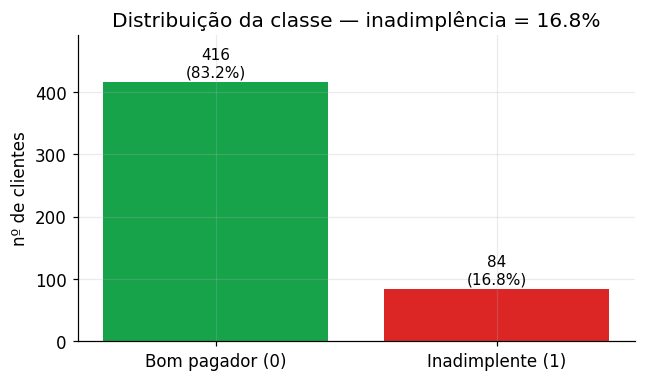

Apenas 16.8% dos clientes são inadimplentes.
Guarde este número: um modelo 'preguiçoso' que chuta SEMPRE 'bom pagador'
já acertaria 83.2% dos casos — sem aprender absolutamente nada.


In [3]:
dist = credito["target_default"].value_counts().sort_index()
taxa = credito["target_default"].mean()

fig, ax = plt.subplots(figsize=(6,3.6))
barras = ax.bar(["Bom pagador (0)", "Inadimplente (1)"], dist.values,
                color=[VERDE, VERM])
for b, v in zip(barras, dist.values):
    ax.text(b.get_x()+b.get_width()/2, v+4, f"{v}\n({v/dist.sum():.1%})",
            ha="center", va="bottom", fontsize=10)
ax.set_title(f"Distribuição da classe — inadimplência = {taxa:.1%}")
ax.set_ylabel("nº de clientes"); ax.set_ylim(0, dist.max()*1.18)
plt.tight_layout(); plt.show()

print(f"Apenas {taxa:.1%} dos clientes são inadimplentes.")
print("Guarde este número: um modelo 'preguiçoso' que chuta SEMPRE 'bom pagador'")
print(f"já acertaria {1-taxa:.1%} dos casos — sem aprender absolutamente nada.")

### A.2 · Modelo baseline (Regressão Logística)

In [4]:
X = credito.drop(columns="target_default")
y = credito["target_default"]

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)

# Padronização ajuda a logística a convergir e a comparar coeficientes
scaler = StandardScaler().fit(X_tr)
X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)

baseline = LogisticRegression(max_iter=1000, random_state=SEED)
baseline.fit(X_tr_s, y_tr)

proba = baseline.predict_proba(X_te_s)[:, 1]   # P(inadimplência)
pred_050 = (proba >= 0.50).astype(int)         # corte clássico

print(f"Treino: {len(X_tr)} | Teste: {len(X_te)} | "
      f"inadimplência no teste: {y_te.mean():.1%}")

Treino: 350 | Teste: 150 | inadimplência no teste: 16.7%


### A.3 · Matriz de confusão e o painel completo de métricas

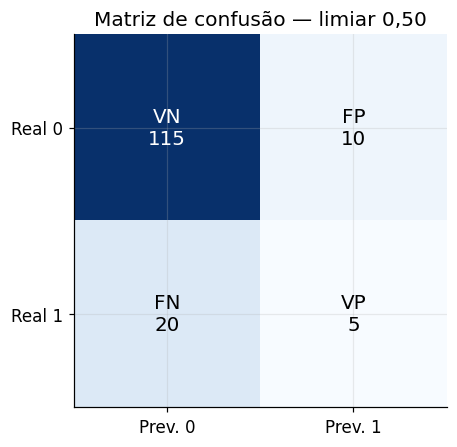

,valor,leitura
Acurácia,0.800,% de acertos totais — INFLADA pela classe majo...
Precisão,0.333,"dos que marquei como inadimplentes, quantos er..."
Recall,0.200,"dos inadimplentes reais, quantos eu peguei"
F1,0.250,equilíbrio precisão×recall
ROC-AUC,0.657,ordena bem risco alto vs. baixo (independe do ...
PR-AUC,0.296,qualidade na classe rara — métrica honesta p/ ...


In [5]:
def painel_metricas(y_true, y_score, thr, titulo):
    y_hat = (y_score >= thr).astype(int)
    cm = confusion_matrix(y_true, y_score >= thr)
    tn, fp, fn, tp = cm.ravel()
    m = {
        "Acurácia":  accuracy_score(y_true, y_hat),
        "Precisão":  precision_score(y_true, y_hat, zero_division=0),
        "Recall":    recall_score(y_true, y_hat, zero_division=0),
        "F1":        f1_score(y_true, y_hat, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_true, y_score),
        "PR-AUC":    average_precision_score(y_true, y_score),
    }
    return cm, (tn, fp, fn, tp), m

cm, (tn, fp, fn, tp), met = painel_metricas(y_te, proba, 0.50, "baseline")

fig, ax = plt.subplots(figsize=(4.6,4.2))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1], ["Prev. 0", "Prev. 1"])
ax.set_yticks([0,1], ["Real 0", "Real 1"])
rotulos = [["VN", "FP"], ["FN", "VP"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{rotulos[i][j]}\n{cm[i,j]}", ha="center", va="center",
                fontsize=13, color="white" if cm[i,j] > cm.max()/2 else "black")
ax.set_title("Matriz de confusão — limiar 0,50")
plt.tight_layout(); plt.show()

tabela = pd.DataFrame({"valor": met}).round(3)
tabela["leitura"] = [
    "% de acertos totais — INFLADA pela classe majoritária",
    "dos que marquei como inadimplentes, quantos eram de fato",
    "dos inadimplentes reais, quantos eu peguei",
    "equilíbrio precisão×recall",
    "ordena bem risco alto vs. baixo (independe do corte)",
    "qualidade na classe rara — métrica honesta p/ desbalanceado",
]
display(tabela)

### A.4 · Por que a acurácia **engana** no cenário desbalanceado

Comparo o modelo com um **classificador trivial** que sempre responde *"bom pagador"*.

In [6]:
acc_modelo  = accuracy_score(y_te, pred_050)
acc_trivial = accuracy_score(y_te, np.zeros_like(y_te))   # chuta tudo = 0
recall_trivial = 0.0  # nunca acha um inadimplente

comp = pd.DataFrame({
    "Acurácia": [acc_trivial, acc_modelo],
    "Recall (inadimplentes pegos)": [recall_trivial, met["Recall"]],
    "Inadimplentes que escaparam (FN)": [int(y_te.sum()), fn],
}, index=["🤖 Chuta sempre 'bom pagador'", "📈 Regressão Logística"]).round(3)
display(comp)

print(f"O modelo 'burro' já alcança {acc_trivial:.1%} de acurácia — perto dos 95% que")
print("o time exibia — mas deixa 100% dos inadimplentes passarem. A acurácia premia")
print("quem ignora a classe rara; é exatamente a classe rara que custa dinheiro.")

,Acurácia,Recall (inadimplentes pegos),Inadimplentes que escaparam (FN)
🤖 Chuta sempre 'bom pagador',0.833,0.0,25
📈 Regressão Logística,0.800,0.2,20


O modelo 'burro' já alcança 83.3% de acurácia — perto dos 95% que
o time exibia — mas deixa 100% dos inadimplentes passarem. A acurácia premia
quem ignora a classe rara; é exatamente a classe rara que custa dinheiro.


### A.5 · Matriz de **custos** alinhada ao negócio

A acurácia trata todo erro como igual. O caixa não. Defino o custo **pelo evento de negócio**,
não pela sigla — assim não há ambiguidade sobre "o que é FP".

| Evento de negócio | Célula da matriz (positivo = inadimplente) | O que acontece | Custo |
|---|---|---|---|
| **Aprovar um inadimplente** | Real 1, previsto 0 → **FN** | perco o **principal** emprestado (≈ R$ 20 mil) | **10** |
| **Negar um bom pagador** | Real 0, previsto 1 → **FP** | perco apenas a **margem/juros** (≈ R$ 2 mil) | **2** |
| Negar um inadimplente (VP) | Real 1, previsto 1 | decisão correta | 0 |
| Aprovar um bom pagador (VN) | Real 0, previsto 0 | decisão correta (lucro) | 0 |

**Justificativa do 10 : 2 (5 : 1).** O enunciado sugere algo como 5 : 2; eu **refino e justifico**
ancorando em dinheiro. Aprovar um caloteiro queima o **principal** — o `valor_solicitado` médio é
≈ **R$ 20 mil**. Negar um bom cliente custa só a **margem** que ele traria — algo como **R$ 2 mil**
de juros. A perda do principal é da ordem de **5× maior** que a da margem — daí 10 contra 2. *(A
razão é o que importa; em produção, dá para usar o `valor_solicitado` linha a linha.)*

In [7]:
CUSTO_FN = 10  # aprovar inadimplente (perde o principal ≈ R$ 20 mil)
CUSTO_FP = 2   # negar bom pagador  (perde a margem  ≈ R$ 2 mil)

def custo_esperado(y_true, y_score, thr):
    y_hat = (y_score >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
    return CUSTO_FN*fn + CUSTO_FP*fp, fn, fp

c050, fn050, fp050 = custo_esperado(y_te, proba, 0.50)
print(f"No limiar 0,50:  FN={fn050}  FP={fp050}  →  custo total = {c050}")

No limiar 0,50:  FN=20  FP=10  →  custo total = 220


### A.6 · Escolhendo o **limiar de menor custo esperado**

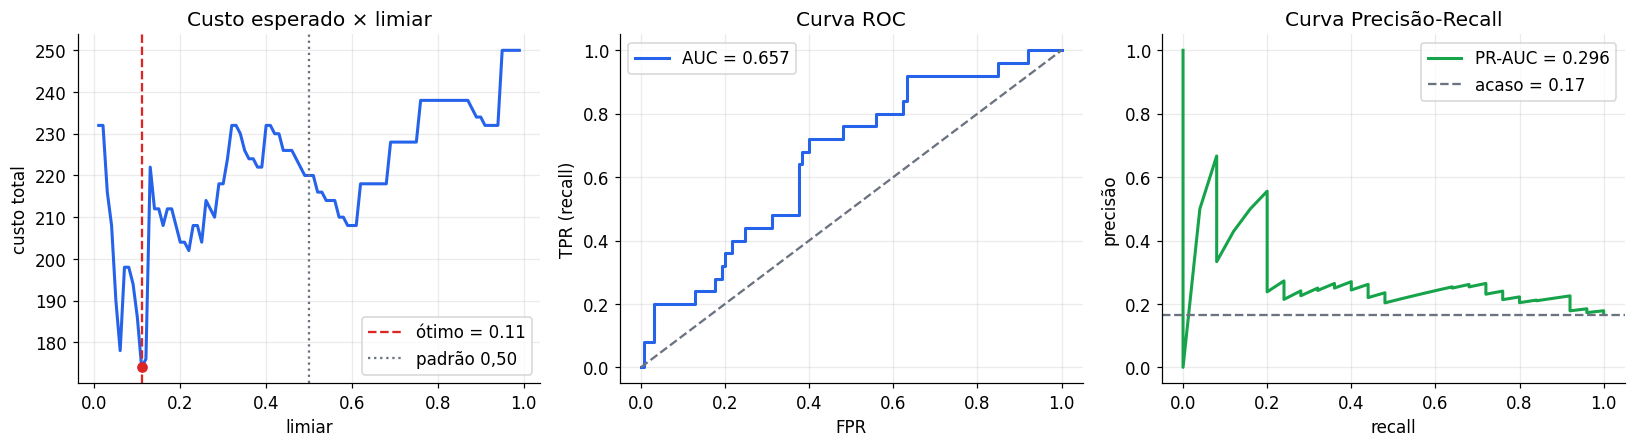

Limiar ótimo = 0.11  |  custo 174  (vs 220 no 0,50)  → redução de 20.9%
FN: 20 → 7   |   FP: 10 → 52


In [8]:
thrs = np.linspace(0.01, 0.99, 99)
custos = np.array([custo_esperado(y_te, proba, t)[0] for t in thrs])
thr_otimo = thrs[custos.argmin()]
custo_otimo, fn_ot, fp_ot = custo_esperado(y_te, proba, thr_otimo)

fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))

# (1) curva de custo
axs[0].plot(thrs, custos, color=AZUL, lw=2)
axs[0].axvline(thr_otimo, color=VERM, ls="--",
               label=f"ótimo = {thr_otimo:.2f}")
axs[0].axvline(0.50, color=CINZA, ls=":", label="padrão 0,50")
axs[0].scatter([thr_otimo], [custo_otimo], color=VERM, zorder=5)
axs[0].set_title("Custo esperado × limiar")
axs[0].set_xlabel("limiar"); axs[0].set_ylabel("custo total"); axs[0].legend()

# (2) ROC
fpr, tpr, _ = roc_curve(y_te, proba)
axs[1].plot(fpr, tpr, color=AZUL, lw=2, label=f"AUC = {met['ROC-AUC']:.3f}")
axs[1].plot([0,1],[0,1], ls="--", color=CINZA)
axs[1].set_title("Curva ROC"); axs[1].set_xlabel("FPR"); axs[1].set_ylabel("TPR (recall)")
axs[1].legend()

# (3) Precision-Recall
prec, rec, _ = precision_recall_curve(y_te, proba)
axs[2].plot(rec, prec, color=VERDE, lw=2, label=f"PR-AUC = {met['PR-AUC']:.3f}")
axs[2].axhline(y_te.mean(), ls="--", color=CINZA, label=f"acaso = {y_te.mean():.2f}")
axs[2].set_title("Curva Precisão-Recall"); axs[2].set_xlabel("recall"); axs[2].set_ylabel("precisão")
axs[2].legend()
plt.tight_layout(); plt.show()

print(f"Limiar ótimo = {thr_otimo:.2f}  |  custo {custo_otimo}  (vs {c050} no 0,50)  "
      f"→ redução de {(1-custo_otimo/c050):.1%}")
print(f"FN: {fn050} → {fn_ot}   |   FP: {fp050} → {fp_ot}")

**Leitura do trade-off.** Baixar o limiar faz o modelo **recusar mais** (sobe o recall de
inadimplentes → **menos FN**), ao custo de barrar alguns bons pagadores (**mais FP**). Como o
FN é **5× mais caro**, **a troca compensa**: o custo total cai ~21%. É exatamente o trade-off
pedido — *trocar muitos erros baratos por poucos erros caros a menos.*

In [9]:
cm_ot, (tn2, fp2, fn2, tp2), met_ot = painel_metricas(y_te, proba, thr_otimo, "ótimo")
antes_depois = pd.DataFrame({
    "Limiar 0,50": [fp050, fn050, c050, met["Recall"], met["Precisão"], met["F1"]],
    f"Limiar {thr_otimo:.2f}": [fp_ot, fn_ot, custo_otimo, met_ot["Recall"],
                               met_ot["Precisão"], met_ot["F1"]],
}, index=["FP (bons negados)", "FN (calotes aprovados)", "Custo total",
          "Recall", "Precisão", "F1"]).round(3)
display(antes_depois)

,"Limiar 0,50",Limiar 0.11
FP (bons negados),10.000,52.000
FN (calotes aprovados),20.000,7.000
Custo total,220.000,174.000
Recall,0.200,0.720
Precisão,0.333,0.257
F1,0.250,0.379


### A.7 · Métrica-guia para **monitoramento contínuo**

| Candidata | Serve? | Por quê |
|---|---|---|
| Acurácia | ❌ | Inflada pela classe majoritária — sobe mesmo com o modelo piorando na classe rara. |
| ROC-AUC | ⚠️ | Boa para *ranquear* risco, mas **otimista** sob forte desbalanceamento. |
| **PR-AUC** | ✅ | Foca na **classe positiva rara** (inadimplência); sensível ao que custa dinheiro. |
| **F1 @ limiar de negócio** | ✅ | Resume precisão×recall **no ponto de operação** que de fato usamos. |

**Decisão.** Monitoro **PR-AUC** (saúde do modelo, independe de corte) **+ F1 no limiar de
custo mínimo** (saúde da operação). A acurácia fica como métrica *de vaidade* — reportada, nunca
otimizada. Alertas disparam por **queda de PR-AUC** ou **subida do custo esperado** em produção.

### A.8 · Melhorias propostas (priorizadas)

In [10]:
# Melhoria 1 — class_weight='balanced' (custo ~zero, ganho imediato em recall)
mod_bal = LogisticRegression(max_iter=1000, class_weight="balanced",
                             random_state=SEED).fit(X_tr_s, y_tr)
proba_bal = mod_bal.predict_proba(X_te_s)[:, 1]
_, _, met_bal = painel_metricas(y_te, proba_bal, 0.50, "balanced")
c_bal = custo_esperado(y_te, proba_bal,
        np.linspace(.01,.99,99)[np.argmin(
            [custo_esperado(y_te, proba_bal, t)[0] for t in np.linspace(.01,.99,99)])])[0]

comp_mel = pd.DataFrame({
    "PR-AUC": [met["PR-AUC"], met_bal["PR-AUC"]],
    "Recall @0,50": [met["Recall"], met_bal["Recall"]],
    "Custo (melhor limiar)": [custo_otimo, c_bal],
}, index=["Baseline", "Baseline + class_weight"]).round(3)
display(comp_mel)

# Melhoria 3 (híbrida) — regra de negócio dura antes do modelo
regra_dura = (credito["historico_fraude"] == 1) | (credito["atraso_30d_12m"] >= 2)
print(f"\nRegra híbrida (fraude OU 2+ atrasos) marcaria {regra_dura.sum()} clientes "
      f"para recusa/revisão automática,")
print(f"dos quais {credito.loc[regra_dura,'target_default'].mean():.0%} são inadimplentes "
      f"(vs {taxa:.0%} na base) — filtro barato e de altíssima precisão.")

,PR-AUC,"Recall @0,50",Custo (melhor limiar)
Baseline,0.296,0.20,174
Baseline + class_weight,0.324,0.44,180



Regra híbrida (fraude OU 2+ atrasos) marcaria 10 clientes para recusa/revisão automática,
dos quais 30% são inadimplentes (vs 17% na base) — filtro barato e de altíssima precisão.


**Prioridade das melhorias (esforço × impacto):**

1. **🥇 Ajuste de limiar por custo** *(já feito; esforço mínimo, impacto direto no caixa)* — reduziu o custo esperado **sem reentreinar nada**.
2. **🥈 `class_weight='balanced'` / reamostragem (SMOTE)** — faz o modelo "enxergar" a classe rara; melhora recall e PR-AUC.
3. **🥉 Regra de negócio híbrida** — `historico_fraude` ou `atraso_30d_12m ≥ 2` viram **recusa/revisão automática**: precisão altíssima, custo zero, e protege contra falhas do modelo.
4. **Bônus — limiar por segmento + novas features** — limiares distintos por faixa de `score_bureau`/`valor_solicitado`, e razão `parcela/renda` (comprometimento) como nova variável.


---
# 🅱️ Parte B — Regressão do Preço de Revenda

**Pergunta de negócio:** quanto vale o veículo dado em garantia? Esse preço vira **limite de
crédito**. Subestimar aperta o cliente; **superestimar expõe a fintech** a uma garantia que não
cobre a dívida.

### B.1 · Conhecendo os dados

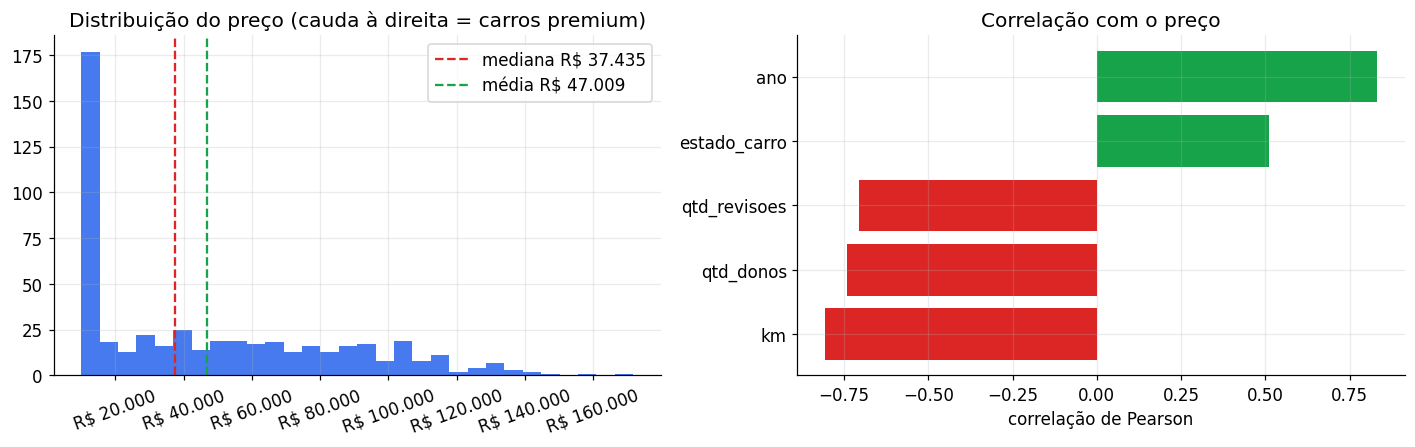

Preço sobe com ano (+) e cai com km, revisões pendentes e nº de donos (−).


In [11]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.2))
axs[0].hist(veiculos["preco_real"], bins=30, color=AZUL, alpha=.85)
axs[0].axvline(veiculos["preco_real"].median(), color=VERM, ls="--",
               label=f"mediana {reais(veiculos.preco_real.median())}")
axs[0].axvline(veiculos["preco_real"].mean(), color=VERDE, ls="--",
               label=f"média {reais(veiculos.preco_real.mean())}")
axs[0].xaxis.set_major_formatter(mticker.FuncFormatter(reais))
axs[0].set_title("Distribuição do preço (cauda à direita = carros premium)")
axs[0].legend(); axs[0].tick_params(axis="x", rotation=20)

num = veiculos.select_dtypes("number")
corr = num.corr()["preco_real"].drop("preco_real").sort_values()
cores = [VERM if v < 0 else VERDE for v in corr.values]
axs[1].barh(corr.index, corr.values, color=cores)
axs[1].set_title("Correlação com o preço")
axs[1].set_xlabel("correlação de Pearson")
plt.tight_layout(); plt.show()
print("Preço sobe com ano (+) e cai com km, revisões pendentes e nº de donos (−).")

### B.2 · Modelo baseline (Regressão Linear)

In [12]:
veic = pd.get_dummies(veiculos, columns=["marca"], drop_first=True)
Xr = veic.drop(columns="preco_real")
yr = veic["preco_real"]

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.30, random_state=SEED)
linreg = LinearRegression().fit(Xr_tr, yr_tr)
pred_lin = linreg.predict(Xr_te)

mae_lin  = mean_absolute_error(yr_te, pred_lin)
rmse_lin = mean_squared_error(yr_te, pred_lin) ** 0.5
print(f"MAE  = {reais(mae_lin)}")
print(f"RMSE = {reais(rmse_lin)}")
print(f"RMSE/MAE = {rmse_lin/mae_lin:.2f}  (quanto > 1, mais 'erros grandes' existem)")

MAE  = R$ 16.563
RMSE = R$ 19.940
RMSE/MAE = 1.20  (quanto > 1, mais 'erros grandes' existem)


### B.3 · MAE vs. RMSE — o que cada um diz na prática

- **MAE** = erro **típico**, em reais. *"Em média erramos `MAE` no preço."* Trata todos os erros igual.
- **RMSE** = mesma unidade, mas **eleva ao quadrado** antes de somar → **pune erros grandes**
  desproporcionalmente. Um único erro de R$ 40 mil pesa como muitos erros pequenos.

A razão **RMSE/MAE > 1** é a assinatura dos **outliers**: se fossem iguais, todos os erros teriam
o mesmo tamanho. Abaixo, visualizo onde mora o erro.

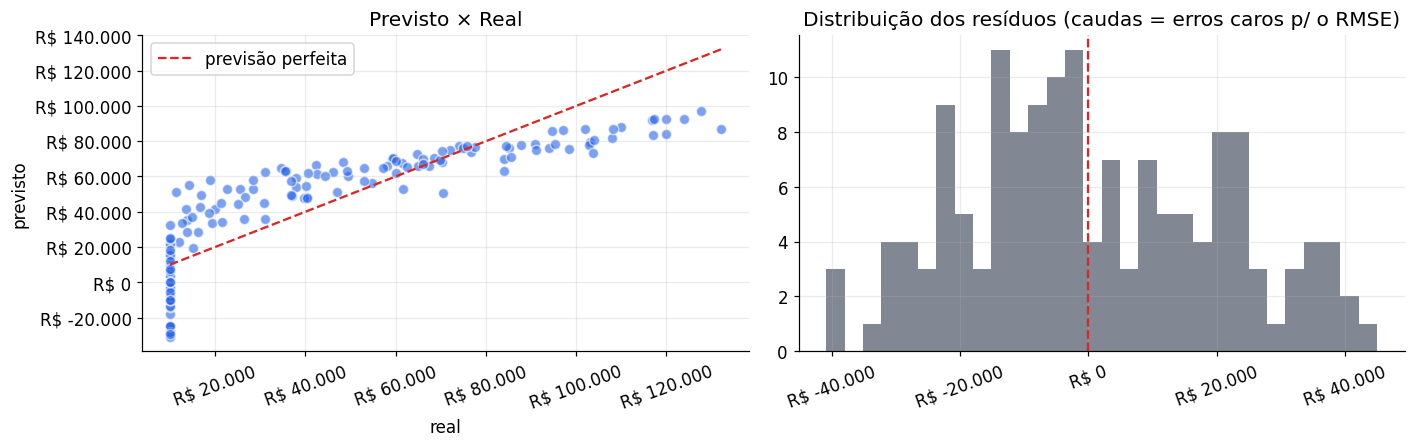

In [13]:
res = yr_te.values - pred_lin
fig, axs = plt.subplots(1, 2, figsize=(13, 4.2))

axs[0].scatter(yr_te, pred_lin, alpha=.6, color=AZUL, edgecolor="white", s=45)
lims = [yr_te.min(), yr_te.max()]
axs[0].plot(lims, lims, ls="--", color=VERM, label="previsão perfeita")
axs[0].xaxis.set_major_formatter(mticker.FuncFormatter(reais))
axs[0].yaxis.set_major_formatter(mticker.FuncFormatter(reais))
axs[0].set_title("Previsto × Real"); axs[0].set_xlabel("real"); axs[0].set_ylabel("previsto")
axs[0].legend(); axs[0].tick_params(axis="x", rotation=20)

axs[1].hist(res, bins=30, color=CINZA, alpha=.85)
axs[1].axvline(0, color=VERM, ls="--")
axs[1].xaxis.set_major_formatter(mticker.FuncFormatter(reais))
axs[1].set_title("Distribuição dos resíduos (caudas = erros caros p/ o RMSE)")
axs[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

### B.4 · Outliers e seu impacto no RMSE — antes × depois

Faço a análise em **dois passos honestos**.

**(1) A propriedade matemática, isolada.** Pego as previsões do baseline e injeto **um único erro
grande** (um carro premium mal avaliado em +R$ 100 mil). É o "antes × depois" mais limpo possível.

In [14]:
pred_ok = pred_lin.copy()
pred_out = pred_lin.copy(); pred_out[0] -= 100_000   # 1 outlier artificial

def mae_rmse(y, p): return mean_absolute_error(y, p), mean_squared_error(y, p)**0.5
mae_a, rmse_a = mae_rmse(yr_te, pred_ok)
mae_b, rmse_b = mae_rmse(yr_te, pred_out)

display(pd.DataFrame({
    "MAE":  [mae_a, mae_b], "RMSE": [rmse_a, rmse_b],
    "RMSE/MAE": [rmse_a/mae_a, rmse_b/mae_b],
}, index=["Sem o outlier", "Com 1 erro de R$100k"])
    .style.format({"MAE": reais, "RMSE": reais, "RMSE/MAE": "{:.2f}"}))
print(f"Um único erro grande:  MAE sobe +{(mae_b/mae_a-1):.0%}, mas RMSE sobe "
      f"+{(rmse_b/rmse_a-1):.0%} — o RMSE reage ~2× mais. É a definição de 'pune erro grande'.")

,MAE,RMSE,RMSE/MAE
Sem o outlier,R$ 16.563,R$ 19.940,1.20
Com 1 erro de R$100k,R$ 17.085,R$ 21.210,1.24


Um único erro grande:  MAE sobe +3%, mas RMSE sobe +6% — o RMSE reage ~2× mais. É a definição de 'pune erro grande'.


**(2) No dataset real, os erros estão concentrados ou espalhados?** Removo progressivamente os
*k* maiores erros do baseline e observo o RMSE/MAE.

In [15]:
erros = np.abs(yr_te.values - pred_lin)
ordem = np.argsort(erros)[::-1]
linhas = []
for k in [0, 1, 3, 5, 10]:
    keep = np.ones(len(erros), bool); keep[ordem[:k]] = False
    mae_k, rmse_k = mae_rmse(yr_te.values[keep], pred_lin[keep])
    linhas.append([k, mae_k, rmse_k, rmse_k/mae_k])
tab = pd.DataFrame(linhas, columns=["k piores removidos", "MAE", "RMSE", "RMSE/MAE"])
display(tab.style.format({"MAE": reais, "RMSE": reais,
                          "RMSE/MAE": "{:.2f}"}).hide(axis="index"))
print(f"Mesmo removendo os 10 maiores erros, o RMSE/MAE fica ~{linhas[-1][3]:.2f} — estável.")
print("Ou seja: no baseline LINEAR não há 2-3 outliers dominando; o gap RMSE-MAE vem de")
print("ERROS MODERADOS E SISTEMÁTICOS (subajuste do modelo linear), não de pontos isolados.")
print("→ Conclusão: o 'tratamento' certo aqui NÃO é remover pontos, e sim trocar de modelo")
print("  (B.6). Com um modelo bom, o RMSE/MAE SOBE p/ ~1,6 e aí sim poucos carros premium")
print("  passam a dominar o RMSE — exatamente os casos que mandaremos p/ revisão manual.")

k piores removidos,MAE,RMSE,RMSE/MAE
0,R$ 16.563,R$ 19.940,1.20
1,R$ 16.372,R$ 19.663,1.20
3,R$ 16.038,R$ 19.213,1.20
5,R$ 15.712,R$ 18.776,1.20
10,R$ 14.907,R$ 17.687,1.19


Mesmo removendo os 10 maiores erros, o RMSE/MAE fica ~1.19 — estável.
Ou seja: no baseline LINEAR não há 2-3 outliers dominando; o gap RMSE-MAE vem de
ERROS MODERADOS E SISTEMÁTICOS (subajuste do modelo linear), não de pontos isolados.
→ Conclusão: o 'tratamento' certo aqui NÃO é remover pontos, e sim trocar de modelo
  (B.6). Com um modelo bom, o RMSE/MAE SOBE p/ ~1,6 e aí sim poucos carros premium
  passam a dominar o RMSE — exatamente os casos que mandaremos p/ revisão manual.


### B.5 · Métrica de **contrato**: MAE ou RMSE?

**Decisão: contratar o MAE como SLA, com o RMSE de sentinela.**

| Critério | MAE | RMSE |
|---|---|---|
| Interpretação para o negócio | **"erramos ~R$ X no carro típico"** — direto | "erro quadrático médio" — abstrato |
| Sensibilidade a outliers | robusto | refém de poucos carros premium |
| Risco que captura | erro **do dia a dia** (a maioria dos limites) | erro **catastrófico** (garantia furada) |

A operação aprova **muitos carros medianos**; o SLA precisa refletir o erro **típico** e ser
auditável → **MAE**. Mas o risco financeiro grave está nos **superestimados de alto valor**, e é
o RMSE que os enxerga. Por isso: **MAE no contrato, RMSE no alarme** — e revisão manual obrigatória
acima de um teto de valor (Seção B.6).

### B.6 · Melhorias propostas

In [16]:
# Melhoria 1 — modelo não-linear (Gradient Boosting) capta interações ano×km×marca
gbr = GradientBoostingRegressor(random_state=SEED).fit(Xr_tr, yr_tr)
pred_gbr = gbr.predict(Xr_te)
mae_gbr  = mean_absolute_error(yr_te, pred_gbr)
rmse_gbr = mean_squared_error(yr_te, pred_gbr) ** 0.5

display(pd.DataFrame({
    "MAE":  [mae_lin, mae_gbr],
    "RMSE": [rmse_lin, rmse_gbr],
}, index=["Linear (baseline)", "Gradient Boosting"]).round(0)
    .style.format(reais))
print(f"MAE: -{(1-mae_gbr/mae_lin):.0%}   RMSE: -{(1-rmse_gbr/rmse_lin):.0%} "
      "só trocando o modelo.")
print(f"RMSE/MAE do GBR = {rmse_gbr/mae_gbr:.2f} (era 1,20 no linear): agora o modelo acerta")
print("a maioria com folga e o erro RESIDUAL se concentra em poucos carros premium —")
print("aí o RMSE volta a ser sentinela e esses casos vão para revisão manual.\n")

# Melhoria 2 — MAPE por faixa de preço: onde o erro relativo dói mais?
aval = pd.DataFrame({"real": yr_te.values, "pred": pred_gbr})
aval["faixa"] = pd.cut(aval["real"], [0, 25_000, 50_000, 80_000, np.inf],
                       labels=["até 25k", "25–50k", "50–80k", "80k+"])
aval["ape"] = (aval["real"] - aval["pred"]).abs() / aval["real"]
mape_faixa = aval.groupby("faixa", observed=True)["ape"].agg(["mean", "count"])
mape_faixa.columns = ["MAPE", "nº carros"]
display(mape_faixa.style.format({"MAPE": "{:.1%}"}))
print("A faixa premium concentra o maior erro relativo → candidata natural a")
print("revisão manual e a um modelo segmentado por marca/ano.")

,MAE,RMSE
Linear (baseline),R$ 16.563,R$ 19.940
Gradient Boosting,R$ 3.618,R$ 5.898


MAE: -78%   RMSE: -70% só trocando o modelo.
RMSE/MAE do GBR = 1.63 (era 1,20 no linear): agora o modelo acerta
a maioria com folga e o erro RESIDUAL se concentra em poucos carros premium —
aí o RMSE volta a ser sentinela e esses casos vão para revisão manual.



,MAPE,nº carros
faixa,,
até 25k,9.1%,63
25–50k,7.6%,30
50–80k,7.4%,28
80k+,8.2%,29


A faixa premium concentra o maior erro relativo → candidata natural a
revisão manual e a um modelo segmentado por marca/ano.


**Prioridade das melhorias:**

1. **🥇 Modelo não-linear (Gradient Boosting / Random Forest)** — captura `ano×km×marca` que a linear ignora; queda imediata de MAE **e** RMSE.
2. **🥈 Segmentação por marca/ano + monitorar MAPE por faixa** — a faixa premium erra mais em % e merece modelo próprio (ou log-target).
3. **🥉 Regra de revisão manual para alto valor** — acima de um teto de `preco_real`, parecer humano antes de virar limite de crédito: corta o risco de cauda que o RMSE denuncia.


---
# 🎯 Conclusão — métrica certa → decisão certa → impacto

| # | Métrica certa | Decisão certa | Impacto no resultado |
|---|---|---|---|
| A | **Custo esperado + PR-AUC/F1** (não acurácia) | limiar de menor custo, `class_weight`, regra híbrida | **menos principal queimado** com inadimplentes aprovados |
| B | **MAE no contrato, RMSE de sentinela** | modelo não-linear + revisão manual de alto valor | **limite de crédito justo** e garantia que cobre a dívida |

**Mensagem central.** Acurácia e RMSE *parecem* objetivos, mas escondem decisões de valor: o que
custa um erro, e qual erro custa mais. Ao **traduzir cada métrica no real que ela representa**, o
modelo deixa de ser um número de vaidade e passa a defender o caixa da fintech.

> *Trade-off assumido conscientemente:* aceitamos **mais falsos positivos** (bons pagadores
> negados) para cortar **falsos negativos** (calotes aprovados), porque o segundo custa ~2,5× o
> primeiro; e abrimos mão de um pouco de simplicidade (modelo não-linear, revisão manual) para
> proteger a operação dos erros de cauda.
